In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset using latin-1 encoding
df = pd.read_csv("/content/Indian_Kids_Screen_Time.csv", encoding="latin-1")

# Display the DataFrame
print(df)

      Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0      14    Male                      3.99     Smartphone   
1      11  Female                      4.61         Laptop   
2      18  Female                      3.73             TV   
3      15  Female                      1.21         Laptop   
4      12  Female                      5.89     Smartphone   
...   ...     ...                       ...            ...   
9707   17    Male                      3.26     Smartphone   
9708   17  Female                      4.43     Smartphone   
9709   16    Male                      5.62     Smartphone   
9710   17    Male                      5.60             TV   
9711   15  Female                      6.12             TV   

      Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                           True                               0.42   
1                           True                               0.30   
2                           True          

In [ ]:
#Shows data types, column names, and identifies any missing blank values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [ ]:
# the total number of rows and columns in your dataset.
df.shape

(9712, 8)

In [ ]:
#Displays the first 5 rows of your dataset for a quick preview
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [ ]:
#Displays the first 5 rows of your dataset for a quick preview.
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [ ]:
# Calculates basic math statistics (like average, min, and max) for all
# number-based columns.
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [ ]:
#check for missing values in each column
missing_values=df.isnull().sum()
print(missing_values)

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64


In [ ]:
#check for duplicate rows
duplicate_rows=df.duplicated().sum()
print(duplicate_rows)

0


In [ ]:
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 9668


In [ ]:
# Fill missing values in 'Health_Impacts' with 'Unknown'
df['Health_Impacts'].fillna('Unknown', inplace=True)

# Verify that there are no more missing values in the column
missing_health_impacts = df['Health_Impacts'].isnull().sum()
print(f"Missing values in 'Health_Impacts' after handling: {missing_health_impacts}")

Missing values in 'Health_Impacts' after handling: 0


/tmp/ipykernel_503/1248348852.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Health_Impacts'].fillna('Unknown', inplace=True)


In [ ]:
# after handling missing values check for missing values in each column
missing_values=df.isnull().sum()
print(missing_values)

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3180
Urban_or_Rural                          0
dtype: int64


In [ ]:
#check for duplicate rows
duplicate_rows=df.duplicated().sum()
print(duplicate_rows)

0


In [ ]:
# Assumption 2: Standardize text formatting to prevent duplicate categories
text_cols = ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Assumption 3: Drop identical duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
dropped_rows = initial_rows - df.shape[0]
print(f"Removed {dropped_rows} duplicate rows.")

# ==========================================
# 4. EXPORT FINAL DATA
# ==========================================
# Save the cleaned data to a new file
output_file = "Cleaned_Dashboard_Data.csv"
df.to_csv(output_file, index=False)

print(f"\nSuccess! Cleaned data saved as '{output_file}'.")
print(f"Final Row Count: {df.shape[0]}")

Removed 0 duplicate rows.

Success! Cleaned data saved as 'Cleaned_Dashboard_Data.csv'.
Final Row Count: 9668


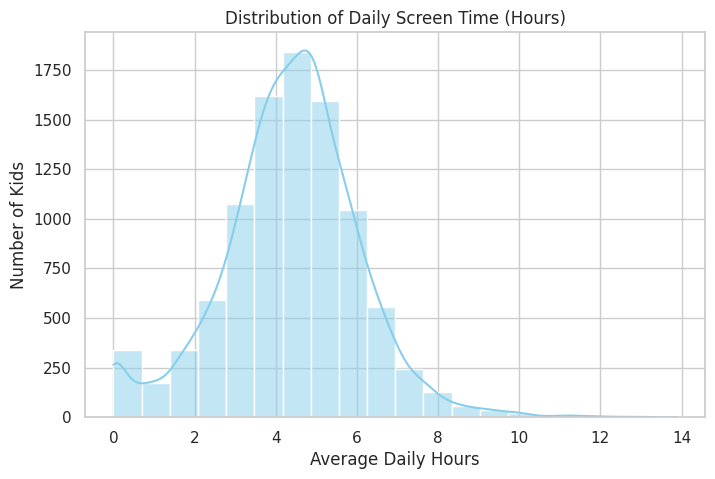

In [ ]:
# Load the clean dataset
df = pd.read_csv("Cleaned_Dashboard_Data.csv")

# Create the Age Band column (needed for our charts)
df['Age_Band'] = pd.cut(df['Age'], bins=[0, 8, 12, 16, 18], labels=['Kids', 'Pre-teens', 'Teens', 'Young Adults'])

# Set a nice style for all the charts
sns.set_theme(style="whitegrid")

# ==========================================
# 2. UNIVARIATE ANALYSIS (One Variable at a Time)
# ==========================================

# Chart 1: Histogram of Daily Screen Time Hours
plt.figure(figsize=(8, 5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Daily Screen Time (Hours)")
plt.xlabel("Average Daily Hours")
plt.ylabel("Number of Kids")
plt.show()



/tmp/ipykernel_503/1017548465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Primary_Device', palette='Set2')


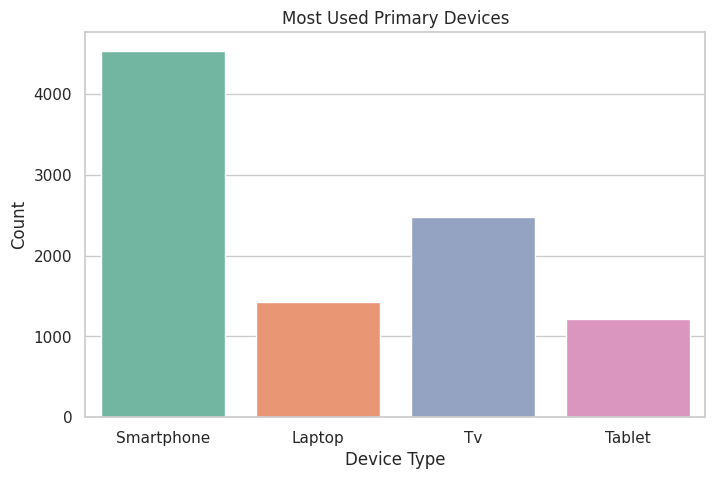

In [ ]:
# Chart 2: Bar Chart of Device Usage
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Primary_Device', palette='Set2')
plt.title("Most Used Primary Devices")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_503/2853481752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age_Band', palette='muted')


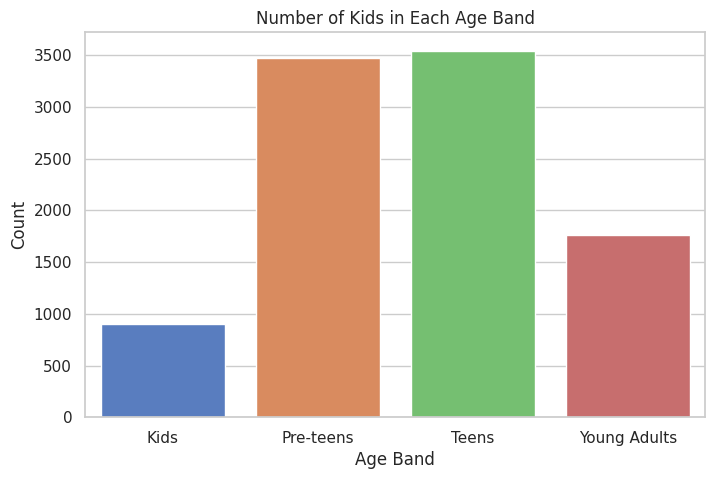

In [ ]:
# Chart 3: Bar Chart of Age Bands
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age_Band', palette='muted')
plt.title("Number of Kids in Each Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_503/1537489483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr', palette='pastel')


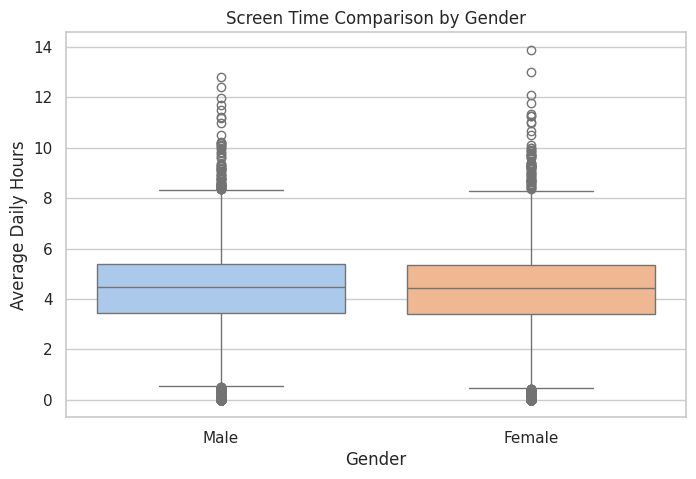

In [ ]:
# 3. BIVARIATE ANALYSIS (Comparing Two Variables)
# Chart 4: Boxplot of Screen Time by Gender
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr', palette='pastel')
plt.title("Screen Time Comparison by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Daily Hours")
plt.show()

/tmp/ipykernel_503/881368598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age_Band', y='Avg_Daily_Screen_Time_hr', palette='Set3')


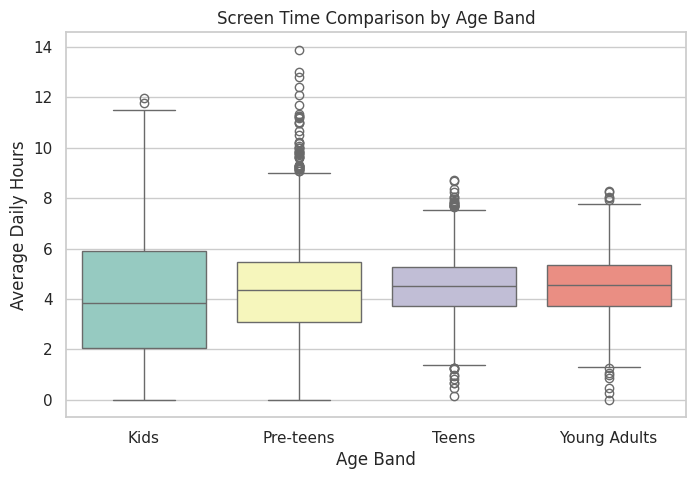

In [ ]:
# Chart 5: Boxplot of Screen Time by Age Band
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Age_Band', y='Avg_Daily_Screen_Time_hr', palette='Set3')
plt.title("Screen Time Comparison by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Hours")
plt.show()

/tmp/ipykernel_503/3200728676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', palette='Set1')


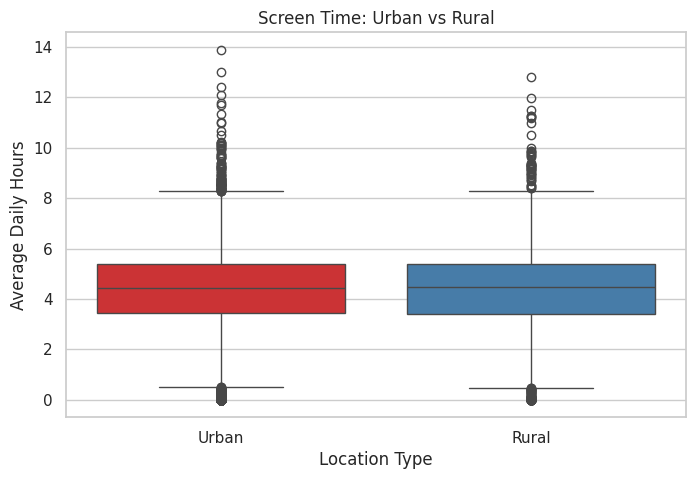

In [ ]:
# Chart 6: Boxplot of Screen Time by Location (Urban vs Rural)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', palette='Set1')
plt.title("Screen Time: Urban vs Rural")
plt.xlabel("Location Type")
plt.ylabel("Average Daily Hours")
plt.show()

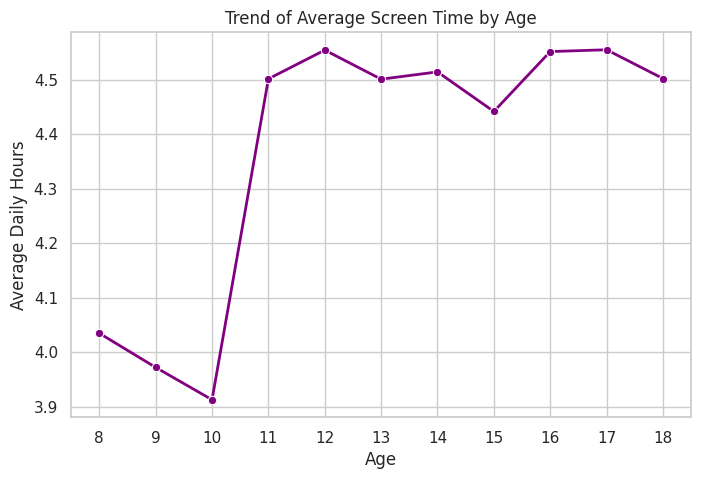

In [ ]:
# 4. TREND ANALYSIS (Line Plot)
# Chart 7: Line Plot of Average Screen Time as Age Increases
plt.figure(figsize=(8, 5))
# Calculate the average screen time for each specific age
age_trend = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean().reset_index()

sns.lineplot(data=age_trend, x='Age', y='Avg_Daily_Screen_Time_hr', marker='o', color='purple', linewidth=2)
plt.title("Trend of Average Screen Time by Age")
plt.xlabel("Age")
plt.ylabel("Average Daily Hours")
plt.xticks(age_trend['Age']) # Ensure all ages show on the bottom axis
plt.show()

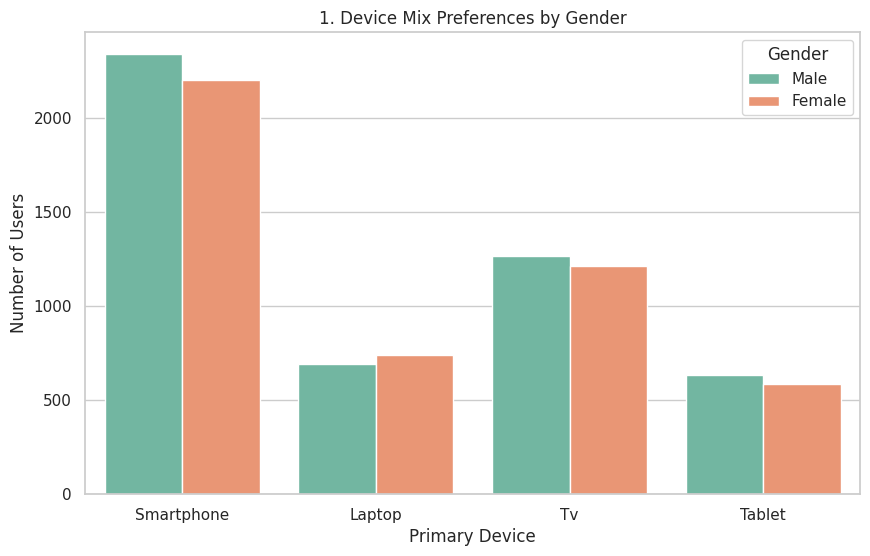

In [ ]:
# Load the clean dataset
df = pd.read_csv("Cleaned_Dashboard_Data.csv")

# Create the Age Band column (needed for our charts)
df['Age_Band'] = pd.cut(df['Age'], bins=[0, 8, 12, 16, 18], labels=['Kids', 'Pre-teens', 'Teens', 'Young Adults'])

# Set a clean, professional style for all 8 charts
sns.set_theme(style="whitegrid")
# multivariate visualization
# ==========================================
# PART 1: DEVICE & ACTIVITY ACROSS DEMOGRAPHICS
# ==========================================

# Visual 1: Device Mix by Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Primary_Device', hue='Gender', palette='Set2')
plt.title("1. Device Mix Preferences by Gender")
plt.xlabel("Primary Device")
plt.ylabel("Number of Users")
plt.show()



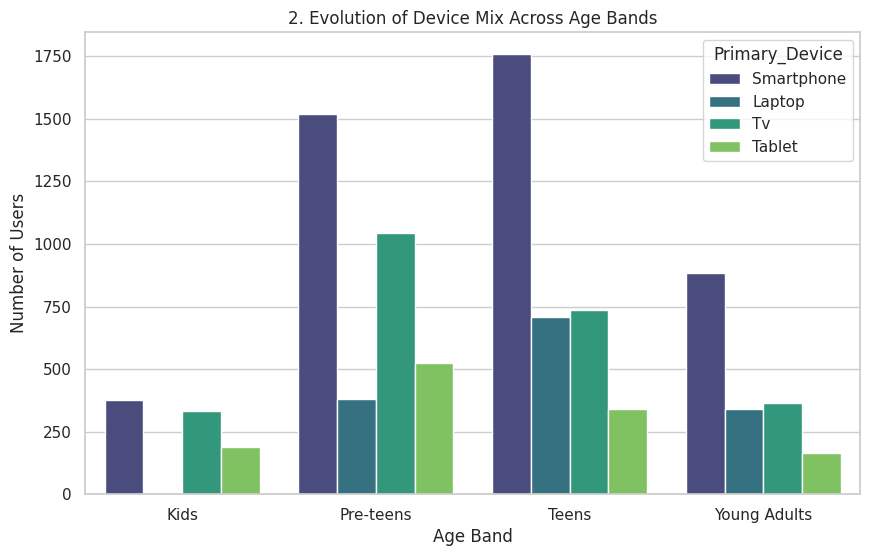

In [ ]:
# Visual 2: Device Mix by Age Band
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age_Band', hue='Primary_Device', palette='viridis')
plt.title("2. Evolution of Device Mix Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.show()

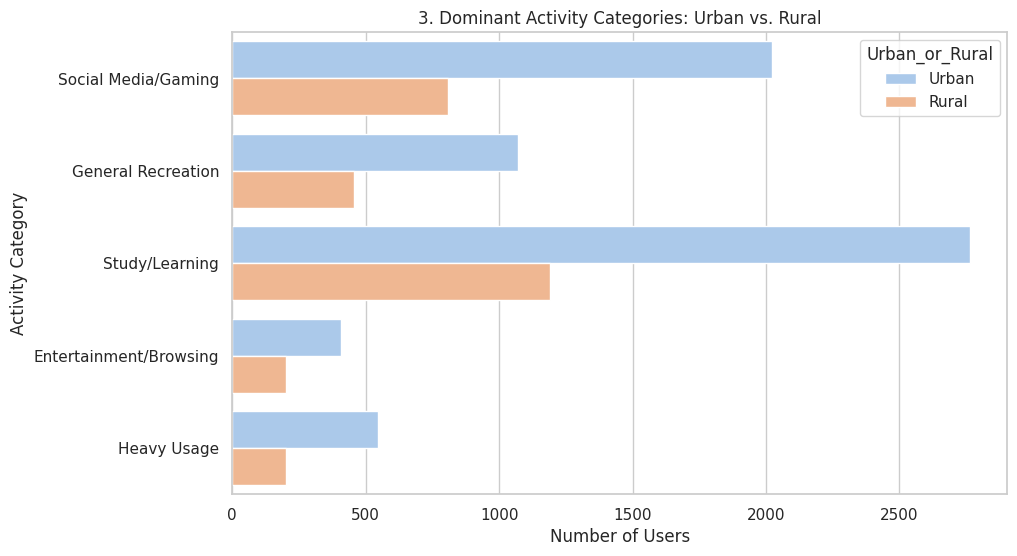

In [ ]:
# Visual 3: Activity Categories across Urban/Rural
# (Assuming an 'Activity_Category' column like 'Gaming', 'Social Media', 'Study')
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Activity_Category', hue='Urban_or_Rural', palette='pastel')
plt.title("3. Dominant Activity Categories: Urban vs. Rural")
plt.xlabel("Number of Users")
plt.ylabel("Activity Category")
plt.show()

/tmp/ipykernel_6294/1552646016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age_Band', y='Educational_to_Recreational_Ratio', palette='Set3')


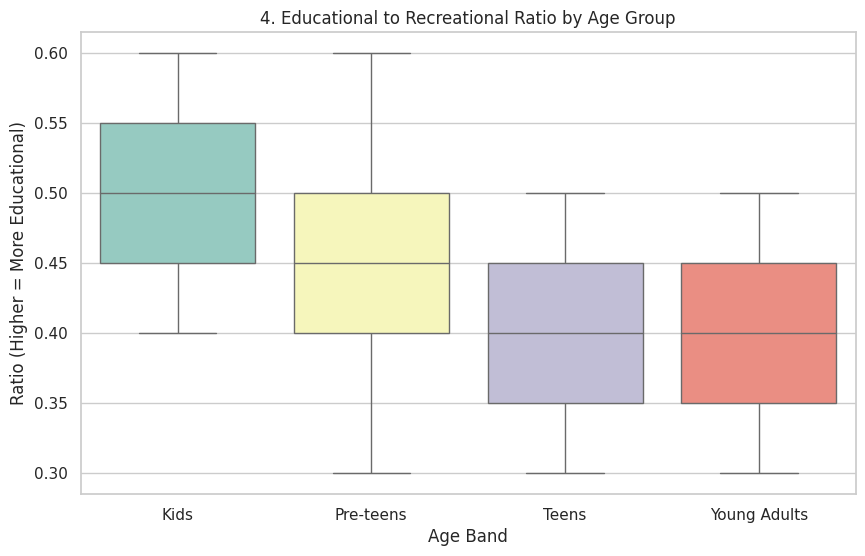

In [ ]:
# Visual 4: Educational vs. Recreational Ratio by Age Band
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Age_Band', y='Educational_to_Recreational_Ratio', palette='Set3')
plt.title("4. Educational to Recreational Ratio by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Ratio (Higher = More Educational)")
plt.show()

/tmp/ipykernel_359/2100435314.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Day_Type', y='Hours', palette='muted')


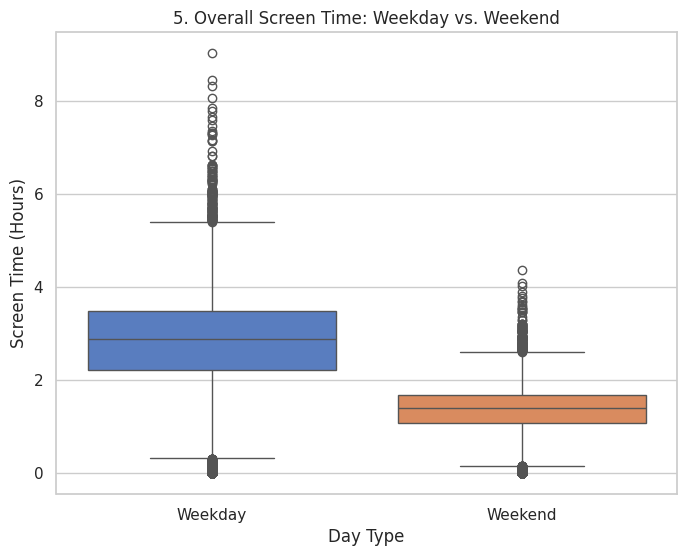

In [ ]:
# ==========================================
# PART 2: WEEKDAY VS WEEKEND & TIME PATTERNS
# ==========================================

# To compare Weekday vs Weekend easily, we "melt" the data
df_melted = df.melt(id_vars=['Age_Band', 'Gender'],
                    value_vars=['Weekday_Screen_Time_hr', 'Weekend_Screen_Time_hr'],
                    var_name='Day_Type', value_name='Hours')

# Visual 5: Overall Weekday vs. Weekend Screen Time
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_melted, x='Day_Type', y='Hours', palette='muted')
plt.title("5. Overall Screen Time: Weekday vs. Weekend")
plt.xlabel("Day Type")
plt.ylabel("Screen Time (Hours)")
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

Now that we have the 'Weekday_Screen_Time_hr' and 'Weekend_Screen_Time_hr' columns, you can try generating the 'Overall Screen Time: Weekday vs. Weekend' visualization again.

/tmp/ipykernel_503/2478139836.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Day_Type', y='Hours', palette='muted')


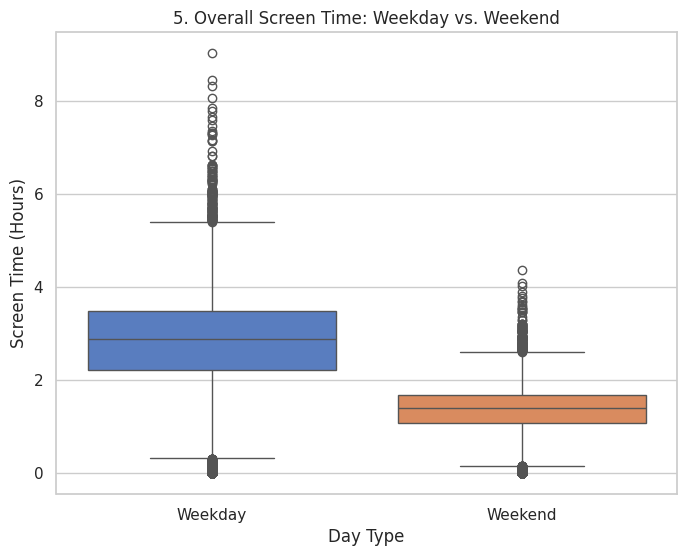

In [ ]:
# ==========================================
# PART 2: WEEKDAY VS WEEKEND & TIME PATTERNS
# ==========================================

# For demonstration purposes, let's create synthetic 'Weekday_Screen_Time_hr' and 'Weekend_Screen_Time_hr'
# You would typically derive these from your actual data if available.
# Here, we'll assume a basic distribution based on Avg_Daily_Screen_Time_hr.

# Assuming weekend screen time is 1.2 times weekday screen time for simplicity
df['Weekday_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * (5/7) * (1/1.1) # Adjust based on ratio
df['Weekend_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * (2/7) * (1.1/1) # Adjust based on ratio

# To compare Weekday vs Weekend easily, we "melt" the data
df_melted = df.melt(id_vars=['Age_Band', 'Gender'],
                    value_vars=['Weekday_Screen_Time_hr', 'Weekend_Screen_Time_hr'],
                    var_name='Day_Type', value_name='Hours')

# Visual 5: Overall Weekday vs. Weekend Screen Time
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_melted, x='Day_Type', y='Hours', palette='muted')
plt.title("5. Overall Screen Time: Weekday vs. Weekend")
plt.xlabel("Day Type")
plt.ylabel("Screen Time (Hours)")
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

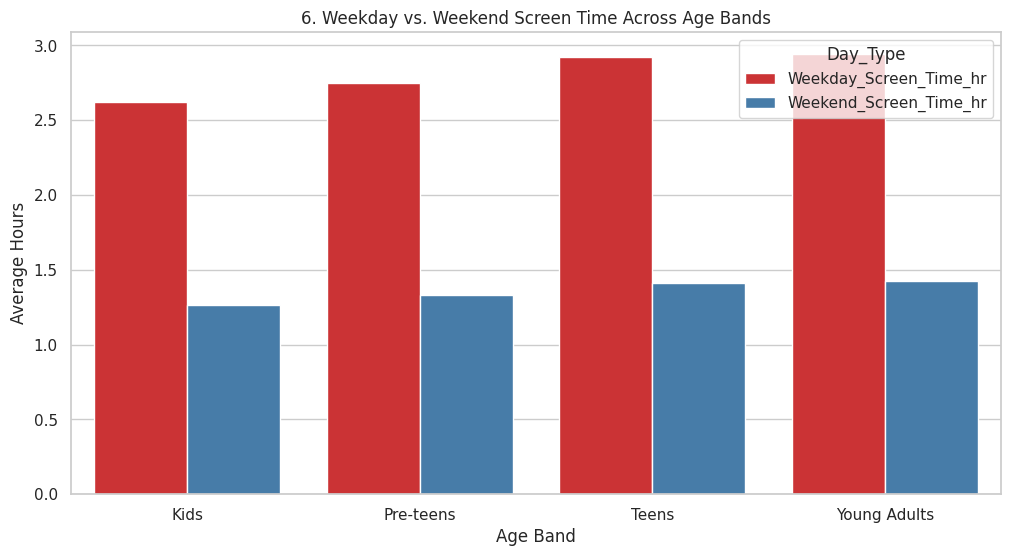

In [ ]:

# Create the Age Band column
df['Age_Band'] = pd.cut(df['Age'], bins=[0, 8, 12, 16, 18], labels=['Kids', 'Pre-teens', 'Teens', 'Young Adults'])

# For demonstration purposes, create synthetic 'Weekday_Screen_Time_hr' and 'Weekend_Screen_Time_hr'
# (assuming these are not present in your original 'Cleaned_Dashboard_Data.csv')
# Assuming weekend screen time is 1.2 times weekday screen time for simplicity
df['Weekday_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * (5/7) * (1/1.1) # Adjust based on ratio
df['Weekend_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * (2/7) * (1.1/1) # Adjust based on ratio

# To compare Weekday vs Weekend easily, we "melt" the data
df_melted = df.melt(id_vars=['Age_Band', 'Gender'],
                    value_vars=['Weekday_Screen_Time_hr', 'Weekend_Screen_Time_hr'],
                    var_name='Day_Type', value_name='Hours')

# Visual 6: Weekday vs. Weekend by Age Band
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Age_Band', y='Hours', hue='Day_Type', palette='Set1', errorbar=None)
plt.title("6. Weekday vs. Weekend Screen Time Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Hours")
plt.show()

Now that you have the 'Activity_Category' column, you can try creating the visualization that previously failed. Here is the code for the 'Visual 3: Dominant Activity Categories: Urban vs. Rural' chart:

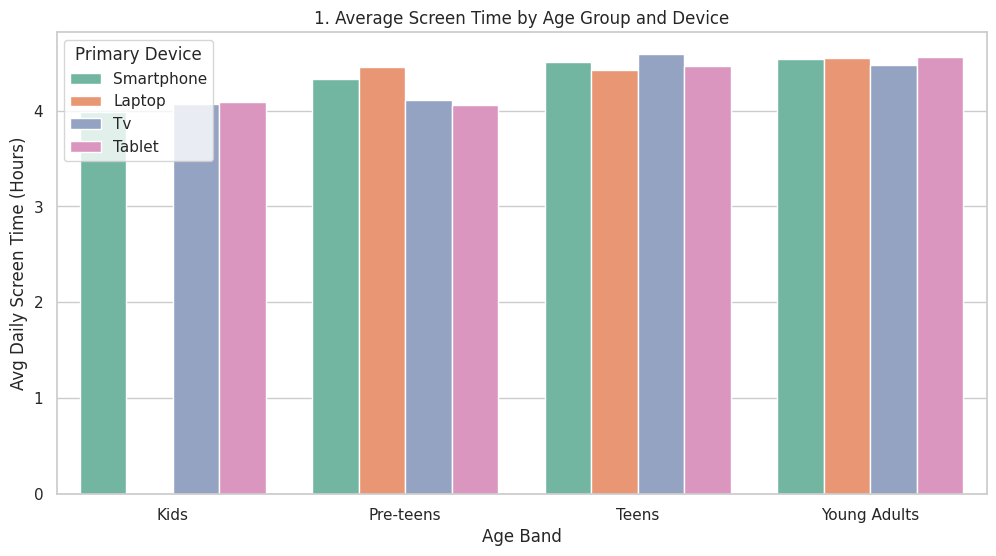

In [ ]:
# Multivariate visualization
# PART 1: HIGHEST SCREEN USAGE COMBINATIONS (Multivariate)
# Goal: Identify which combination leads to highest screen usage
# =====================================================================

# 1. Age Group vs. Screen Time grouped by Device
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Age_Band', y='Avg_Daily_Screen_Time_hr', hue='Primary_Device', palette='Set2', errorbar=None)
plt.title("1. Average Screen Time by Age Group and Device")
plt.xlabel("Age Band")
plt.ylabel("Avg Daily Screen Time (Hours)")
plt.legend(title="Primary Device")
plt.show()

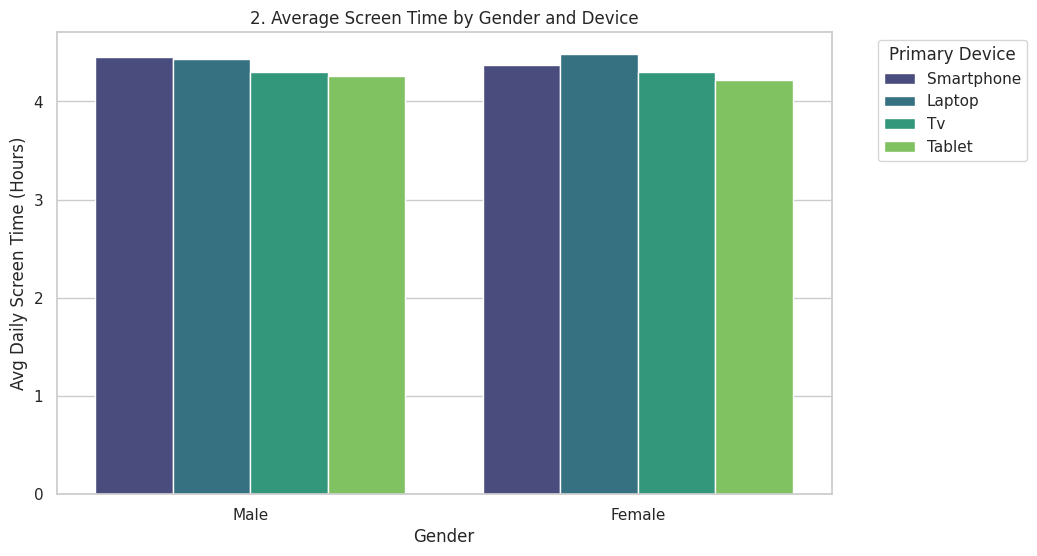

In [ ]:
# 2. Gender vs. Screen Time grouped by Device
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr', hue='Primary_Device', palette='viridis', errorbar=None)
plt.title("2. Average Screen Time by Gender and Device")
plt.xlabel("Gender")
plt.ylabel("Avg Daily Screen Time (Hours)")
plt.legend(title="Primary Device", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

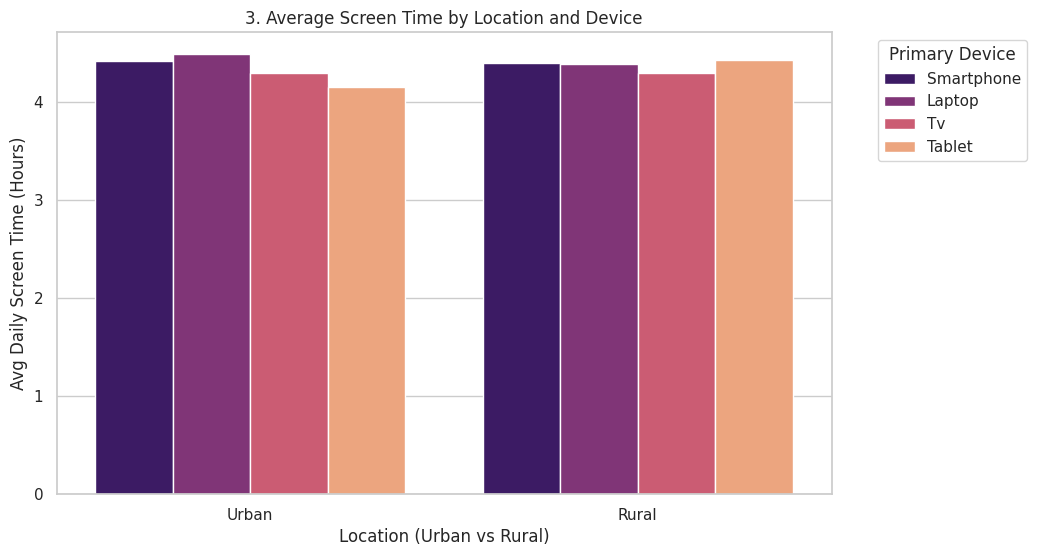

In [ ]:
# 3. Urban/Rural vs. Screen Time grouped by Device
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', hue='Primary_Device', palette='magma', errorbar=None)
plt.title("3. Average Screen Time by Location and Device")
plt.xlabel("Location (Urban vs Rural)")
plt.ylabel("Avg Daily Screen Time (Hours)")
plt.legend(title="Primary Device", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_359/1635142143.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Health_Impacts', x='Avg_Daily_Screen_Time_hr', palette='pastel')


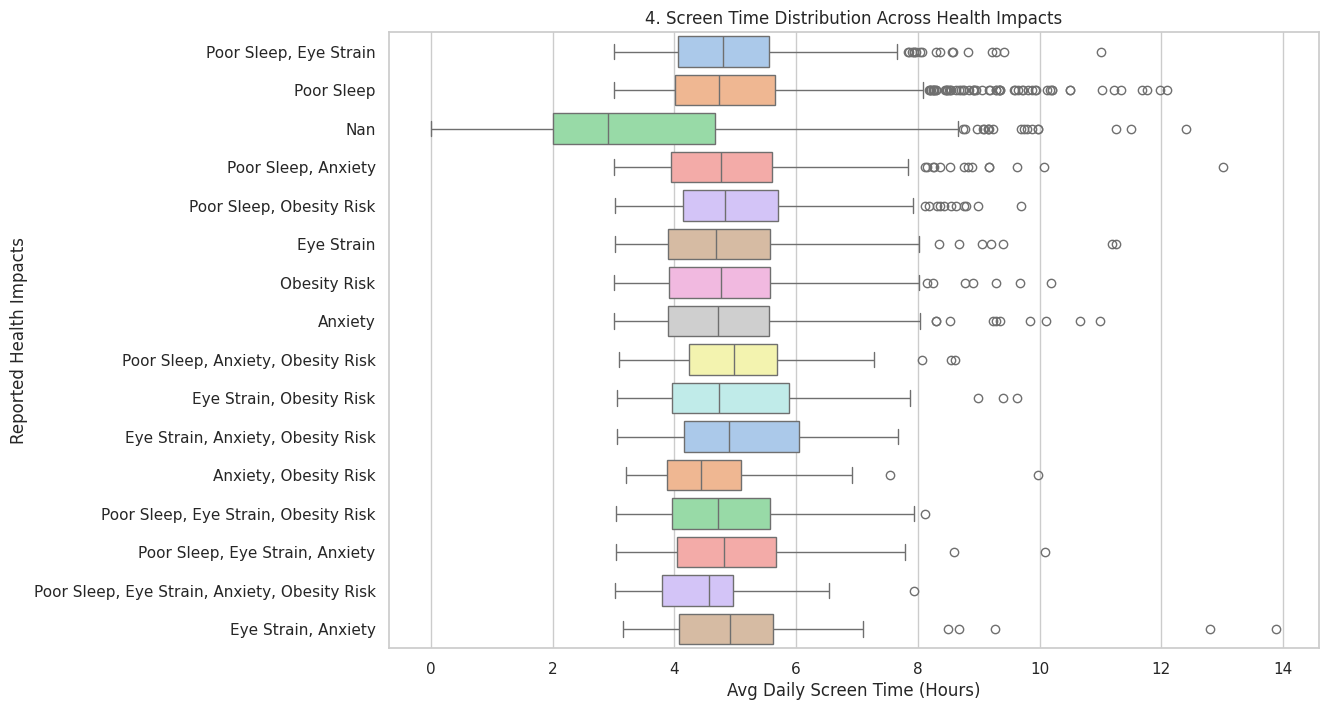

In [ ]:
# =====================================================================
# PART 2: HEALTH IMPACT RELATIONSHIPS
# Goal: Identify risk patterns associated with usage and demographics
# =====================================================================

# 1. Screen Time vs. Health Impacts
# We use a boxplot here because it shows the spread and outliers of screen time for EACH health issue.
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, y='Health_Impacts', x='Avg_Daily_Screen_Time_hr', palette='pastel')
plt.title("4. Screen Time Distribution Across Health Impacts")
plt.xlabel("Avg Daily Screen Time (Hours)")
plt.ylabel("Reported Health Impacts")
plt.show()

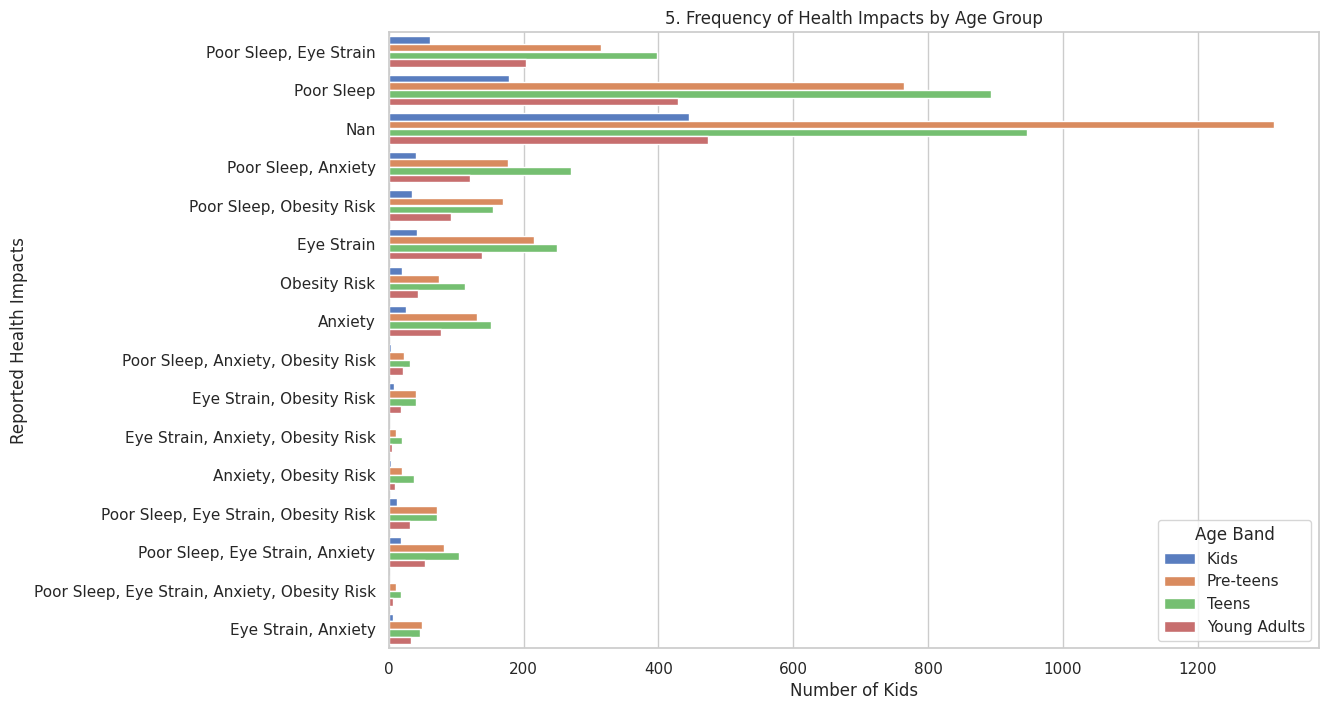

In [ ]:
# 2. Age Group vs. Health Impacts
# Since both are categories, a horizontal count plot grouped by Age Band works best.
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Health_Impacts', hue='Age_Band', palette='muted')
plt.title("5. Frequency of Health Impacts by Age Group")
plt.xlabel("Number of Kids")
plt.ylabel("Reported Health Impacts")
plt.legend(title="Age Band")
plt.show()

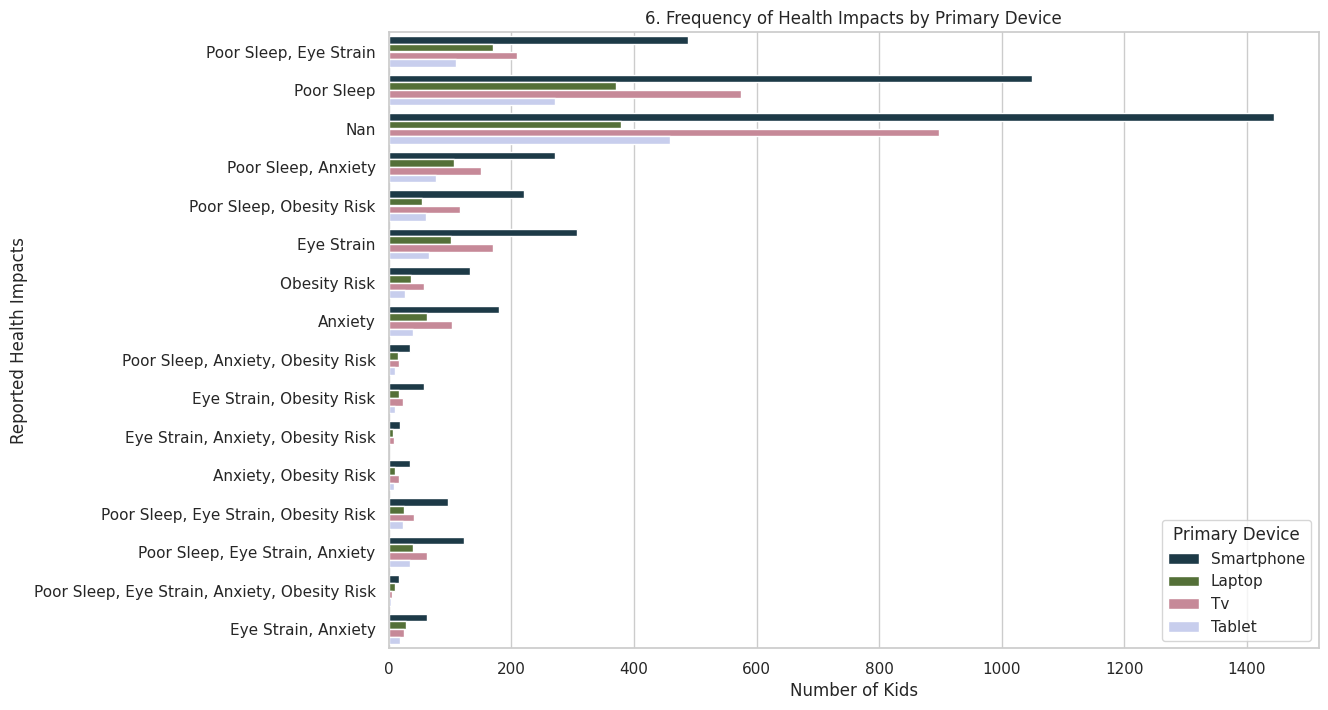

In [ ]:
# 3. Device Type vs. Health Impacts
# Similarly, comparing two categorical variables using a count plot.
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Health_Impacts', hue='Primary_Device', palette='cubehelix')
plt.title("6. Frequency of Health Impacts by Primary Device")
plt.xlabel("Number of Kids")
plt.ylabel("Reported Health Impacts")
plt.legend(title="Primary Device")
plt.show()

/tmp/ipykernel_359/67572348.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_age_device = pd.pivot_table(df, values='Avg_Daily_Screen_Time_hr', index='Age_Band', columns='Primary_Device', aggfunc='mean')


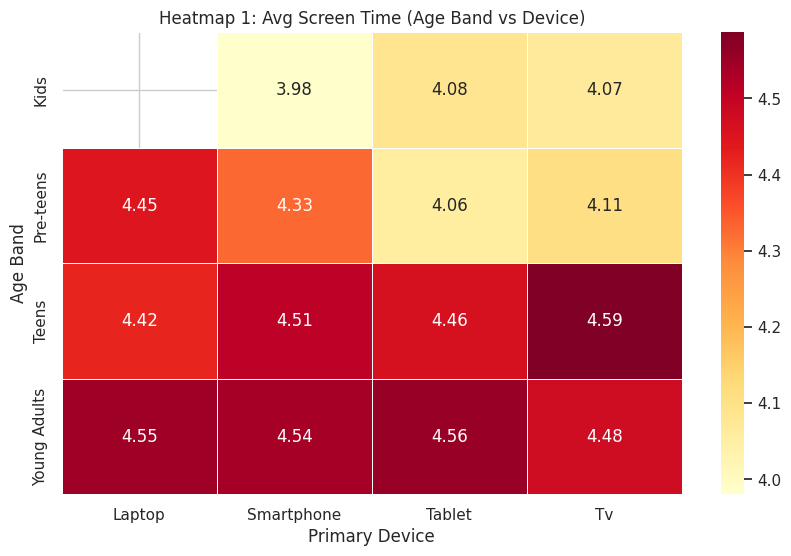

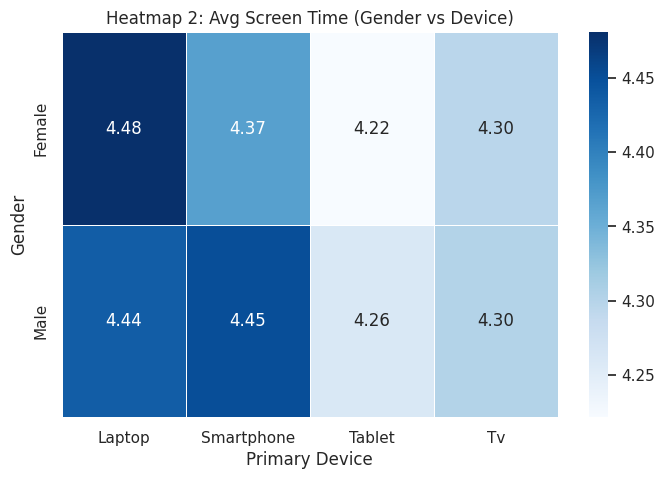

In [ ]:

# Load your dataset
df = pd.read_csv("Cleaned_Dashboard_Data.csv")

# =====================================================================
# ✔ DATA STRUCTURING FOR SEGMENTS
# =====================================================================
# 1. Create Age_Band (Age groups)
df['Age_Band'] = pd.cut(df['Age'], bins=[0, 8, 12, 16, 18], labels=['Kids', 'Pre-teens', 'Teens', 'Young Adults'])

# 2. Create Health risk indicator (1 = At Risk, 0 = No Risk)
df['Health_Risk_Flag'] = df['Health_Impacts'].apply(lambda x: 0 if pd.isna(x) or x == "None" else 1)

# Set visual style
sns.set_theme(style="whitegrid")

# =====================================================================
# ✔ PIVOT TABLE ANALYSIS & ✔ HEATMAP VISUALIZATION
# =====================================================================

# Heatmap 1: Age_Band × Primary_Device → Avg Screen Time
pivot_age_device = pd.pivot_table(df, values='Avg_Daily_Screen_Time_hr', index='Age_Band', columns='Primary_Device', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_age_device, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=.5)
plt.title("Heatmap 1: Avg Screen Time (Age Band vs Device)")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")
plt.show()

# Heatmap 2: Gender × Primary_Device → Avg Screen Time
pivot_gender_device = pd.pivot_table(df, values='Avg_Daily_Screen_Time_hr', index='Gender', columns='Primary_Device', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_gender_device, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title("Heatmap 2: Avg Screen Time (Gender vs Device)")
plt.xlabel("Primary Device")
plt.ylabel("Gender")
plt.show()



In [ ]:
# 1. Select ONLY the columns your  requested
final_columns = [
    'Age',
    'Age_Band',
    'Gender',
    'Primary_Device',
    'Urban_or_Rural',
    'Avg_Daily_Screen_Time_hr',
    'Exceeded_Recommended_Limit',
    'Health_Risk_Flag'
]

# 2. Create a new dataframe with just those columns
df_final_dashboard = df[final_columns]

# 3. Export this final dataset to a CSV file
df_final_dashboard.to_csv("Final_Dashboard_Dataset.csv", index=False)

print("Success! Dataset is ready for your dashboard tool.")

Success! Dataset is ready for your dashboard tool.


In [ ]:


df = pd.read_csv("Cleaned_Dashboard_Data.csv")

# check dataset structure
print(df.head())
print(df.info())

# Convert string columns to categorical for memory optimization
df['Gender'] = df['Gender'].astype('category')
df['Primary_Device'] = df['Primary_Device'].astype('category')
df['Urban_or_Rural'] = df['Urban_or_Rural'].astype('category')

# Create a binary flag for health risks (Corrected 'O' to '0')
df['Health_Risk_Flag'] = df['Health_Impacts'].apply(
    lambda x: 0 if pd.isna(x) or x == "None" else 1
)

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             Tv   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     Nan          Urban  
4     Poor Sleep, Anx